In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

In [2]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 848.2 kB/s eta 0:00:58
    --------------------------------------- 0.8/48.9 MB 771.9 kB/s eta 0:01:03
    --------------------------------------- 0.8/48.9 MB 771.9 kB/s eta 0:01:03
    --------------------------------------- 1.0/48.9 MB 793.0 kB/s eta 0:01:01
   - -------------------------------------- 1.3/48.9 MB 798.5 kB/s eta 0:01:00
   - -------------------------------------- 1.6/48.9 MB 852.0 kB/s eta 0:00:56
   - -------------------------------------- 1.8/48.9 MB 869.9 kB/s eta 0:00:55
   - -------------------------------------- 1.8/48.9 MB 869.9 kB/s eta 0:00:55
   - -------------------------------------- 2.1/48.9 MB 897.5 kB/s eta 0:00:53
   - ----

In [2]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_7_mean",
    "rolling_14_mean",
    "rolling_30_mean",
    "rolling_7_std",
    "rolling_30_std",
    "month",
    "day_of_week",
    "day_of_year",
]


In [3]:
target= 'target'

In [7]:
df = pd.read_csv("processed/tomato_model_ready.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

In [8]:
print(df.shape)
print(df.head())

(2129, 3)
        date   price  was_imputed
0 2020-01-01  1150.0        False
1 2020-01-02  1100.0        False
2 2020-01-03  1125.0        False
3 2020-01-04  1200.0        False
4 2020-01-05  1350.0        False


In [9]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_year"] = df["date"].dt.dayofyear

df["lag_1"] = df["price"].shift(1)
df["lag_7"] = df["price"].shift(7)
df["lag_14"] = df["price"].shift(14)
df["lag_30"] = df["price"].shift(30)

df["rolling_7_mean"] = df["price"].rolling(7).mean()
df["rolling_14_mean"] = df["price"].rolling(14).mean()
df["rolling_30_mean"] = df["price"].rolling(30).mean()

df["rolling_7_std"] = df["price"].rolling(7).std()
df["rolling_30_std"] = df["price"].rolling(30).std()

df["target"] = df["price"].shift(-1)

In [10]:
model_df = df.dropna(
    subset=features + ["target"]
).copy()

In [11]:
print("Model-ready shape:", model_df.shape)
print(model_df[features + ["target"]].isna().sum().sum())

Model-ready shape: (1843, 18)
0


In [12]:
train = model_df[
    model_df["date"].dt.year <= 2023
].copy()

In [13]:
validation = model_df[
    model_df["date"].dt.year == 2024
].copy()

In [14]:
test = model_df[
    model_df["date"].dt.year == 2025
].copy()

In [15]:
print("TRAIN:", len(train))
print("VALIDATION:", len(validation))
print("TEST:", len(test))

TRAIN: 1296
VALIDATION: 292
TEST: 255


In [16]:
X_train = train[features]
y_train = train["target"]

In [17]:
X_val = validation[features]
y_val = validation["target"]

In [18]:
X_test = test[features]
y_test = test["target"]

In [19]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

In [20]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [21]:
val_pred = model.predict(X_val)

In [22]:
val_mae = mean_absolute_error(y_val, val_pred)

In [23]:
val_rmse = np.sqrt(
    mean_squared_error(y_val, val_pred)
)

In [24]:
print(f"Validation MAE : ₹{val_mae:.2f}")
print(f"Validation RMSE: ₹{val_rmse:.2f}")

Validation MAE : ₹309.92
Validation RMSE: ₹584.50


In [25]:
import matplotlib.pyplot as plt

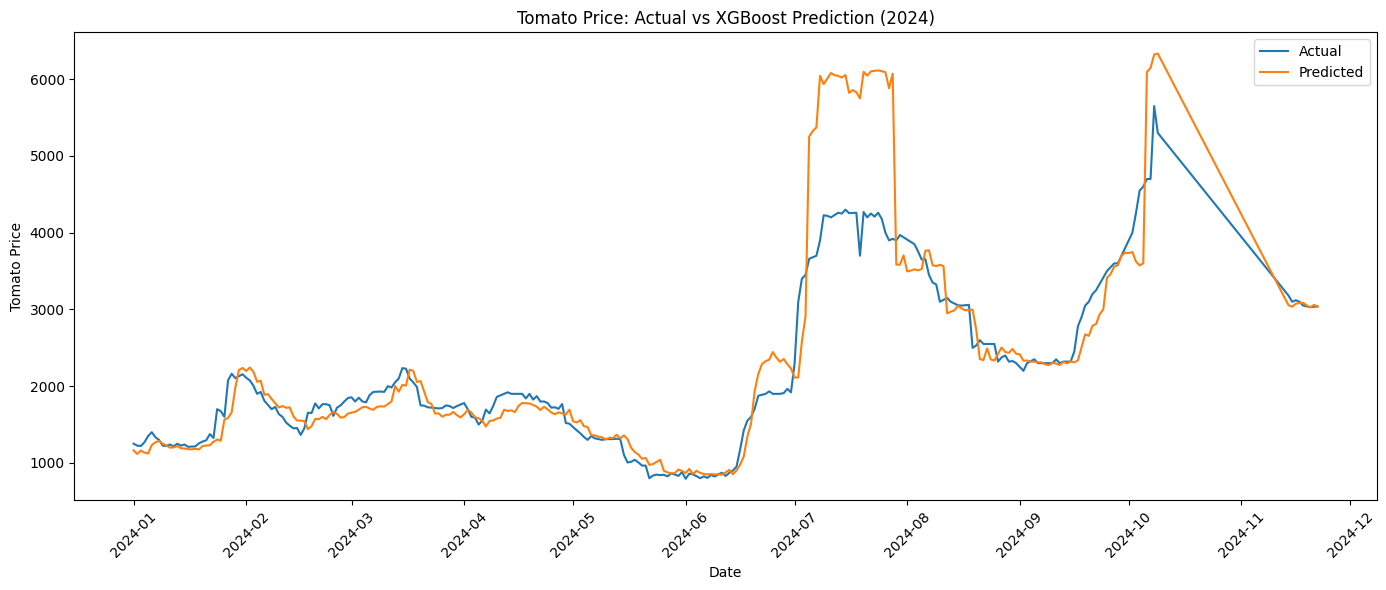

In [27]:
plt.figure(figsize=(14, 6))
plt.plot(
    validation["date"],
    y_val,
    label="Actual"
)
plt.plot(
    validation["date"],
    val_pred,
    label="Predicted"
)
plt.xlabel("Date")
plt.ylabel("Tomato Price")
plt.title("Tomato Price: Actual vs XGBoost Prediction (2024)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

rolling_30_std     0.383189
lag_1              0.336526
rolling_7_mean     0.196629
rolling_14_mean    0.054830
rolling_7_std      0.006272
lag_7              0.004890
lag_14             0.004464
rolling_30_mean    0.003571
lag_30             0.003338
day_of_year        0.002884
month              0.002476
day_of_week        0.000931
dtype: float32


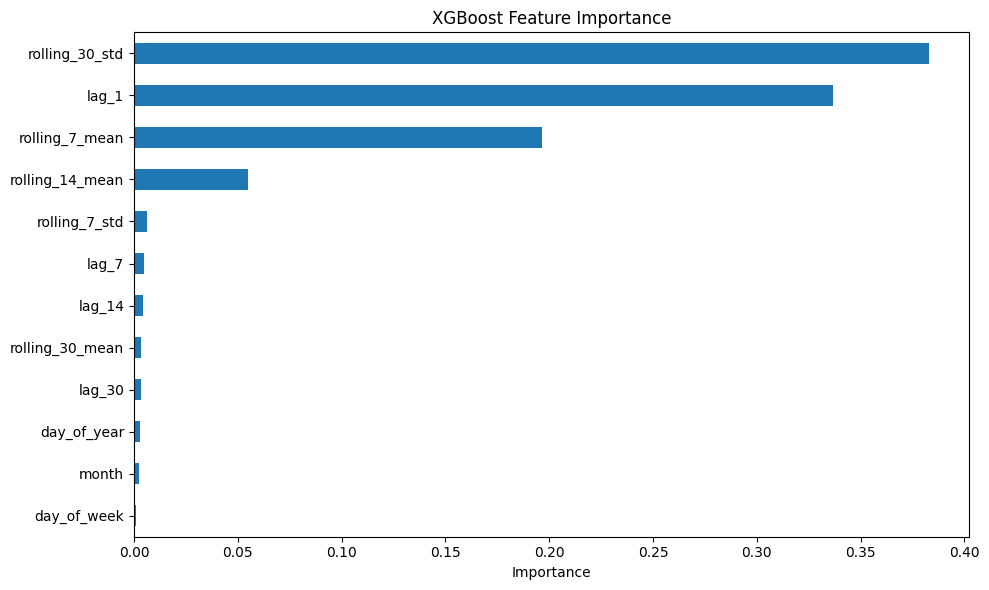

In [29]:
plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [30]:
df["price_change_1"] = df["price"].diff(1)

In [31]:
df["price_change_7"] = (
    df["price"] - df["price"].shift(7)
)

In [37]:
df["price_pct_change_7"] = (
    df["price"].pct_change(7)
)

C:\Users\Kanishka\AppData\Local\Temp\ipykernel_23204\4035872115.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["price"].pct_change(7)


In [33]:
df["rolling_7_min"] = (
    df["price"].rolling(7).min()
)

df["rolling_7_max"] = (
    df["price"].rolling(7).max()
)

df["rolling_30_min"] = (
    df["price"].rolling(30).min()
)

df["rolling_30_max"] = (
    df["price"].rolling(30).max()
)

In [34]:
model_df = df.dropna(
    subset=features + ["target"]
).copy()

In [38]:
model_df.head()

,date,price,was_imputed,year,month,day,day_of_week,day_of_year,lag_1,lag_7,...,rolling_7_std,rolling_30_std,target,price_change_1,price_change_7,price_pct_change_7,rolling_7_min,rolling_7_max,rolling_30_min,rolling_30_max
30,2020-01-31,1167.5,False,2020,1,31,4,31,1250.0,1300.0,...,76.386003,126.343753,1050.0,-82.5,-132.5,-0.101923,1020.0,1250.0,1020.0,1475.0
31,2020-02-01,1050.0,False,2020,2,1,5,32,1167.5,1200.0,...,86.679830,129.595025,1270.0,-117.5,-150.0,-0.125000,1020.0,1250.0,1020.0,1475.0
32,2020-02-02,1270.0,False,2020,2,2,6,33,1050.0,1220.0,...,95.251859,124.863407,1300.0,220.0,50.0,0.040984,1020.0,1270.0,1020.0,1475.0
33,2020-02-03,1300.0,False,2020,2,3,0,34,1270.0,1200.0,...,109.551303,122.859406,1200.0,30.0,100.0,0.083333,1020.0,1300.0,1020.0,1475.0
34,2020-02-04,1200.0,False,2020,2,4,1,35,1300.0,1127.5,...,108.363091,124.787209,1042.0,-100.0,72.5,0.064302,1020.0,1300.0,1020.0,1475.0


In [39]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",

    "rolling_7_mean",
    "rolling_14_mean",
    "rolling_30_mean",

    "rolling_7_std",
    "rolling_30_std",

    "price_change_1",
    "price_change_7",
    "price_pct_change_7",

    "rolling_7_min",
    "rolling_7_max",
    "rolling_30_min",
    "rolling_30_max",

    "month",
    "day_of_week",
    "day_of_year",
]

In [40]:
model_df = df.dropna(
    subset=features + ["target"]
).copy()
print("Model-ready shape:", model_df.shape)
print(model_df[features + ["target"]].isna().sum().sum())

Model-ready shape: (1843, 25)
0


In [41]:
train = model_df[model_df["date"].dt.year <= 2023].copy()
validation = model_df[model_df["date"].dt.year == 2024].copy()
test = model_df[model_df["date"].dt.year == 2025].copy()

print("TRAIN:", len(train))
print("VALIDATION:", len(validation))
print("TEST:", len(test))

TRAIN: 1296
VALIDATION: 292
TEST: 255


In [42]:
X_train = train[features]
y_train = train["target"]

X_val = validation[features]
y_val = validation["target"]

X_test = test[features]
y_test = test["target"]

In [43]:
model_2 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

In [44]:
model_2.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [45]:
val_pred = model_2.predict(X_val)

In [46]:
val_mae = mean_absolute_error(y_val, val_pred)

In [47]:
val_rmse = np.sqrt(
    mean_squared_error(y_val, val_pred)
)

In [48]:
print(f"Validation MAE : ₹{val_mae:.2f}")
print(f"Validation RMSE: ₹{val_rmse:.2f}")

Validation MAE : ₹292.82
Validation RMSE: ₹526.08


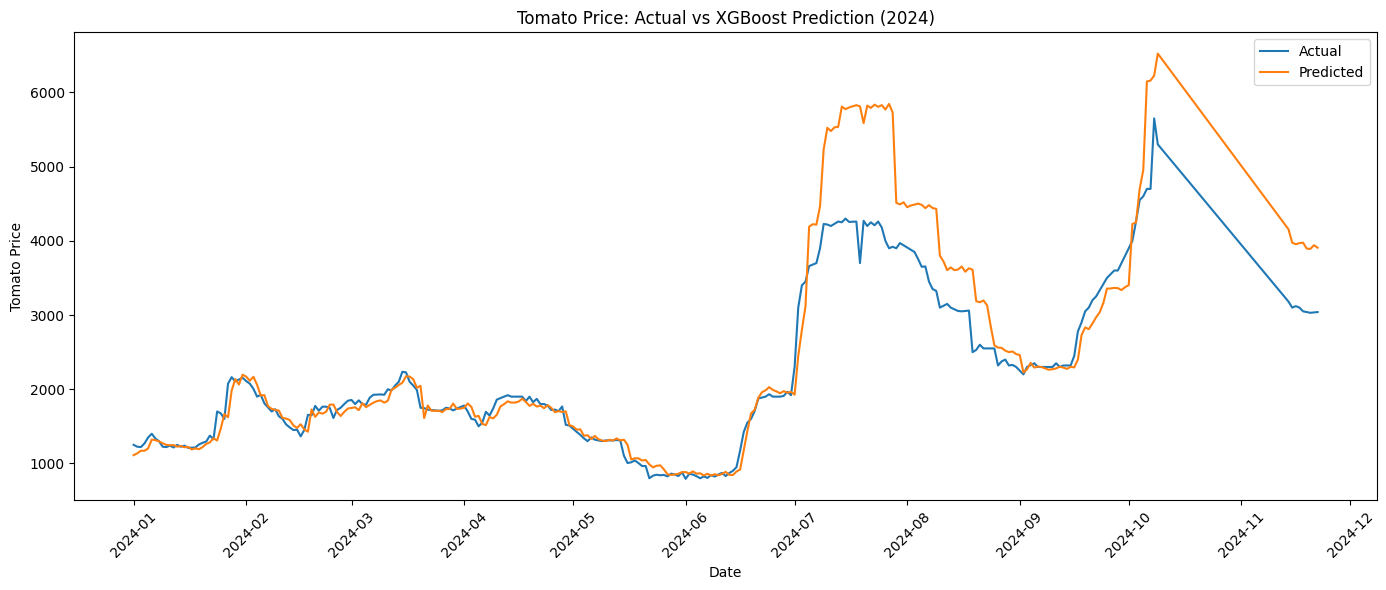

In [49]:
plt.figure(figsize=(14, 6))
plt.plot(
    validation["date"],
    y_val,
    label="Actual"
)
plt.plot(
    validation["date"],
    val_pred,
    label="Predicted"
)
plt.xlabel("Date")
plt.ylabel("Tomato Price")
plt.title("Tomato Price: Actual vs XGBoost Prediction (2024)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
importance = pd.Series(
    model_2.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

rolling_7_max         0.270454
rolling_30_max        0.262245
lag_1                 0.203778
rolling_30_std        0.153942
rolling_7_mean        0.075353
rolling_7_min         0.015053
price_pct_change_7    0.003326
price_change_1        0.002713
price_change_7        0.002332
lag_7                 0.002144
rolling_7_std         0.001626
rolling_14_mean       0.001448
lag_14                0.001141
rolling_30_min        0.001114
day_of_year           0.000891
lag_30                0.000781
month                 0.000728
rolling_30_mean       0.000578
day_of_week           0.000353
dtype: float32


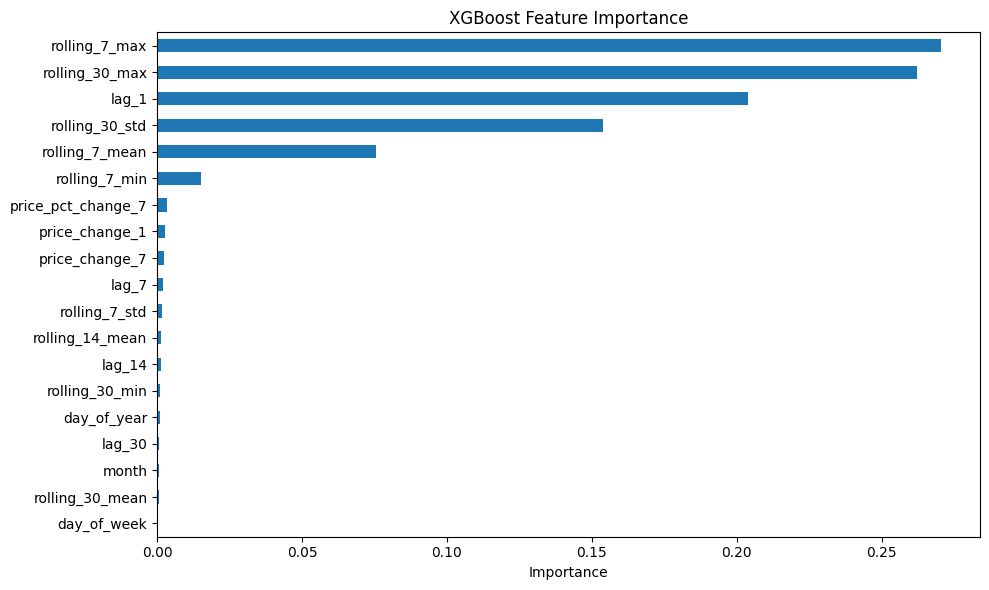

In [52]:
plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [53]:
model3 = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

In [54]:
model4 = XGBRegressor(
    n_estimators=800,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

In [55]:
model5 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

In [56]:
model3.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [57]:
pred_3 = model3.predict(X_val)

In [59]:
mae_3 = mean_absolute_error(y_val, pred_3)
rmse_3 = np.sqrt(mean_squared_error(y_val, pred_3))

print(f"MAE : ₹{mae_3:.2f}")
print(f"RMSE: ₹{rmse_3:.2f}")

MAE : ₹259.87
RMSE: ₹456.65


In [60]:
model4.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
pred_4 = model4.predict(X_val)
mae_4 = mean_absolute_error(y_val, pred_4)
rmse_4 = np.sqrt(mean_squared_error(y_val, pred_4))

print(f"MAE : ₹{mae_4:.2f}")
print(f"RMSE: ₹{rmse_4:.2f}")

MAE : ₹279.93
RMSE: ₹500.04


In [61]:
model5.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
pred_5 = model5.predict(X_val)
mae_5 = mean_absolute_error(y_val, pred_5)
rmse_5 = np.sqrt(mean_squared_error(y_val, pred_5))

print(f"MAE : ₹{mae_5:.2f}")
print(f"RMSE: ₹{rmse_5:.2f}")

MAE : ₹263.98
RMSE: ₹459.65


In [62]:
val_pred_3 = model3.predict(X_val)

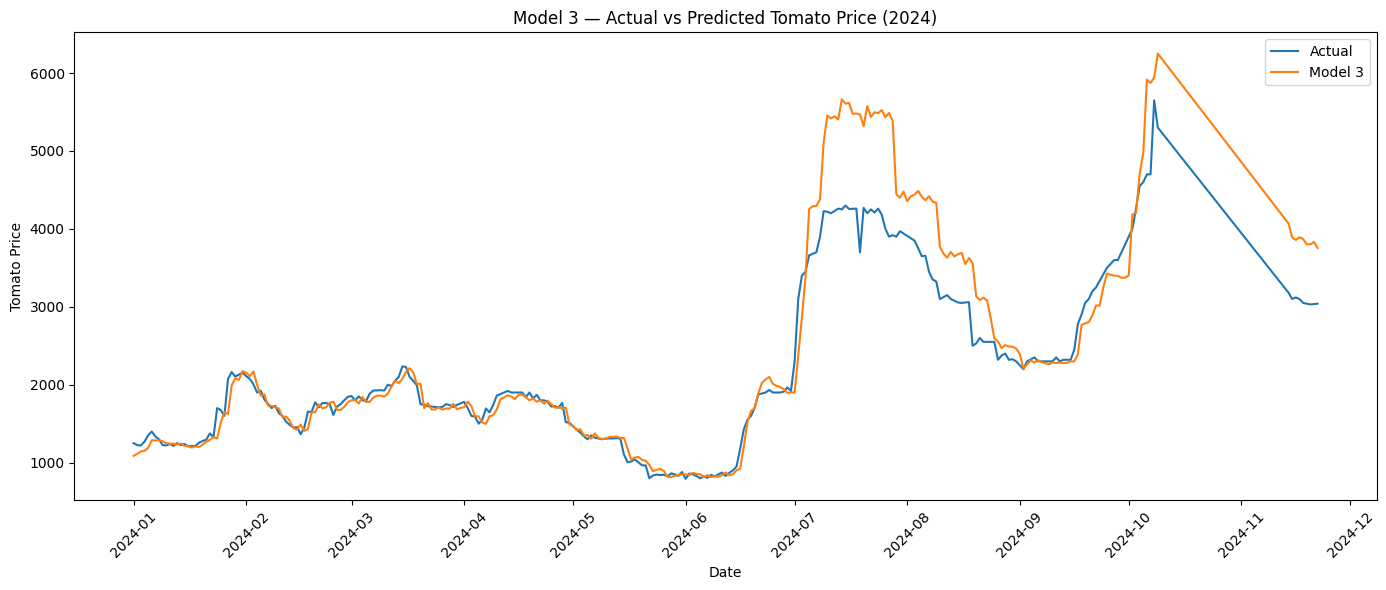

In [63]:
plt.figure(figsize=(14, 6))
plt.plot(
    validation["date"],
    y_val,
    label="Actual"
)
plt.plot(
    validation["date"],
    val_pred_3,
    label="Model 3"
)
plt.xlabel("Date")
plt.ylabel("Tomato Price")
plt.title("Model 3 — Actual vs Predicted Tomato Price (2024)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
test_pred = model3.predict(X_test)

In [65]:
test_mae = mean_absolute_error(y_test, test_pred)

In [66]:
test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

In [67]:
print(f"Test MAE : ₹{test_mae:.2f}")
print(f"Test RMSE: ₹{test_rmse:.2f}")

Test MAE : ₹100.00
Test RMSE: ₹163.64


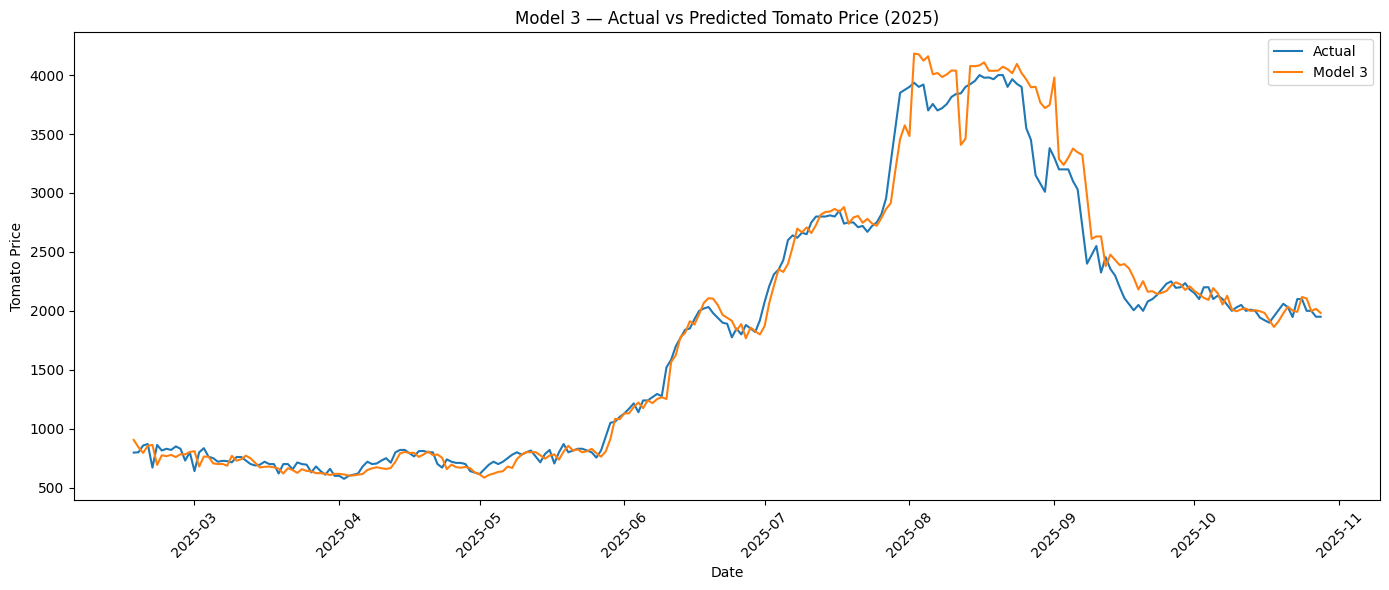

In [68]:
plt.figure(figsize=(14, 6))

plt.plot(
    test["date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["date"],
    test_pred,
    label="Model 3"
)

plt.xlabel("Date")
plt.ylabel("Tomato Price")
plt.title("Model 3 — Actual vs Predicted Tomato Price (2025)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
test_mape = np.mean(
    np.abs((y_test - test_pred) / y_test)
) * 100

print(f"Test MAPE: {test_mape:.2f}%")

Test MAPE: 5.56%


In [70]:
model3.save_model("tomato_xgboost_model.json")

In [72]:
import json

with open("tomato_features.json", "w") as f:
    json.dump(features, f)

In [73]:
def create_features_for_date(history, forecast_date):
    prices = history["price"]

    features = {
        "lag_1": prices.iloc[-1],
        "lag_7": prices.iloc[-7],
        "lag_14": prices.iloc[-14],
        "lag_30": prices.iloc[-30],

        "rolling_7_mean": prices.iloc[-7:].mean(),
        "rolling_14_mean": prices.iloc[-14:].mean(),
        "rolling_30_mean": prices.iloc[-30:].mean(),

        "rolling_7_std": prices.iloc[-7:].std(),
        "rolling_30_std": prices.iloc[-30:].std(),

        "price_change_1": prices.iloc[-1] - prices.iloc[-2],
        "price_change_7": prices.iloc[-1] - prices.iloc[-8],
        "price_pct_change_7": (
            (prices.iloc[-1] - prices.iloc[-8])
            / prices.iloc[-8]
        ),

        "rolling_7_min": prices.iloc[-7:].min(),
        "rolling_7_max": prices.iloc[-7:].max(),

        "rolling_30_min": prices.iloc[-30:].min(),
        "rolling_30_max": prices.iloc[-30:].max(),

        "month": forecast_date.month,
        "day_of_week": forecast_date.dayofweek,
        "day_of_year": forecast_date.dayofyear,
    }

    return pd.DataFrame([features])

In [74]:
def forecast_next_7_days(model, history_df):
    
    history = history_df[["date", "price"]].copy()
    history["date"] = pd.to_datetime(history["date"])
    history = history.sort_values("date").reset_index(drop=True)

    predictions = []

    for _ in range(7):

        last_date = history["date"].iloc[-1]
        forecast_date = last_date + pd.Timedelta(days=1)

        X_future = create_features_for_date(
            history,
            forecast_date
        )

        predicted_price = model.predict(X_future)[0]

        predictions.append({
            "date": forecast_date,
            "predicted_price": predicted_price
        })

        history = pd.concat([
            history,
            pd.DataFrame({
                "date": [forecast_date],
                "price": [predicted_price]
            })
        ], ignore_index=True)

    return pd.DataFrame(predictions)

In [75]:
forecast = forecast_next_7_days(
    model3,
    df[["date", "price"]]
)
print(forecast)

        date  predicted_price
0 2025-10-30      1942.950684
1 2025-10-31      1946.683105
2 2025-11-01      1925.595947
3 2025-11-02      1869.180298
4 2025-11-03      1824.553345
5 2025-11-04      1748.003784
6 2025-11-05      1688.319214


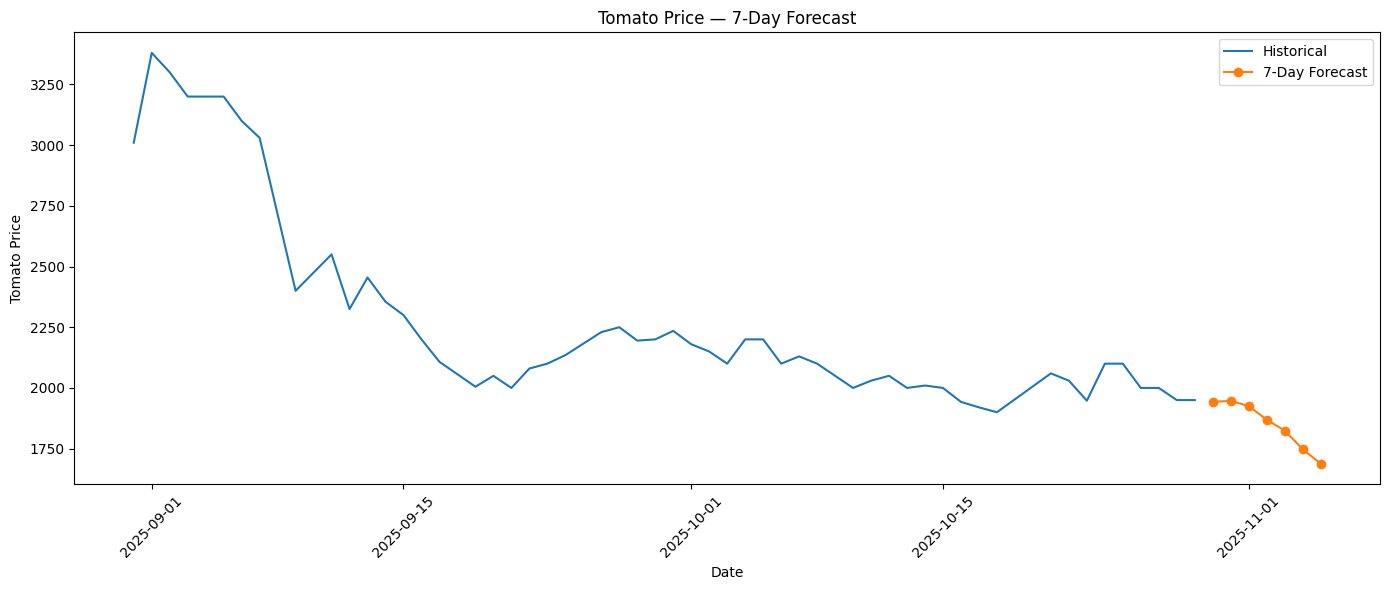

In [76]:
plt.figure(figsize=(14, 6))
recent = df.tail(60)
plt.plot(
    recent["date"],
    recent["price"],
    label="Historical"
)
plt.plot(
    forecast["date"],
    forecast["predicted_price"],
    marker="o",
    label="7-Day Forecast"
)
plt.xlabel("Date")
plt.ylabel("Tomato Price")
plt.title("Tomato Price — 7-Day Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
def backtest_7_days(model, full_df, cutoff_date):
   
    data = full_df.copy()
    data["date"] = pd.to_datetime(data["date"])
    data = data.sort_values("date").reset_index(drop=True)

    cutoff_date = pd.Timestamp(cutoff_date)

    history = data[data["date"] <= cutoff_date][
        ["date", "price"]
    ].copy()

    actual = data[
        (data["date"] > cutoff_date) &
        (data["date"] <= cutoff_date + pd.Timedelta(days=7))
    ][["date", "price"]].copy()

    if len(actual) < 7:
        return None

    forecast = forecast_next_7_days(
        model,
        history
    )

    forecast = forecast.rename(
        columns={"predicted_price": "predicted"}
    )

    result = actual.merge(
        forecast,
        on="date",
        how="inner"
    )

    result["error"] = (
        result["price"] - result["predicted"]
    )

    result["absolute_error"] = (
        result["error"].abs()
    )

    result["percentage_error"] = (
        result["absolute_error"] /
        result["price"].abs()
    ) * 100

    return result

In [81]:
result = backtest_7_days(
    model3,
    df[["date", "price"]],
    "2024-06-01"
)

print(result)

        date  price   predicted      error  absolute_error  percentage_error
0 2024-06-02  792.5  876.400757 -83.900757       83.900757         10.586846
1 2024-06-03  860.0  860.399170  -0.399170        0.399170          0.046415
2 2024-06-04  850.0  849.883667   0.116333        0.116333          0.013686
3 2024-06-05  827.5  823.577332   3.922668        3.922668          0.474038
4 2024-06-06  800.0  817.129700 -17.129700       17.129700          2.141212
5 2024-06-07  825.0  822.158264   2.841736        2.841736          0.344453
6 2024-06-08  805.0  841.734985 -36.734985       36.734985          4.563352


In [82]:
print(
    "7-day MAE:",
    result["absolute_error"].mean()
)

print(
    "7-day MAPE:",
    result["percentage_error"].mean()
)

7-day MAE: 20.72076416015625
7-day MAPE: 2.5957148037320055


In [83]:
cutoff_dates = pd.date_range(
    start="2024-02-01",
    end="2024-12-15",
    freq="7D"
)

all_results = []

for cutoff in cutoff_dates:

    result = backtest_7_days(
        model3,
        df[["date", "price"]],
        cutoff
    )

    if result is not None:
        result["cutoff_date"] = cutoff
        result["horizon"] = range(1, len(result) + 1)

        all_results.append(result)

backtest_results = pd.concat(
    all_results,
    ignore_index=True
)

print(backtest_results.shape)

(322, 8)


In [84]:
overall_mae = (
    backtest_results["absolute_error"].mean()
)

overall_mape = (
    backtest_results["percentage_error"].mean()
)

overall_rmse = np.sqrt(
    (backtest_results["error"] ** 2).mean()
)

print(f"Overall 7-day MAE : ₹{overall_mae:.2f}")
print(f"Overall 7-day RMSE: ₹{overall_rmse:.2f}")
print(f"Overall 7-day MAPE: {overall_mape:.2f}%")

Overall 7-day MAE : ₹673.40
Overall 7-day RMSE: ₹1010.93
Overall 7-day MAPE: 22.38%


In [85]:
horizon_metrics = (
    backtest_results
    .groupby("horizon")
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("error", lambda x: np.sqrt(np.mean(x ** 2))),
        MAPE=("percentage_error", "mean")
    )
)

print(horizon_metrics)

                MAE         RMSE       MAPE
horizon                                    
1        321.501970   540.816059   9.824378
2        557.312306   910.007376  17.585041
3        646.022961   995.395120  20.818939
4        723.784574  1041.881914  24.140716
5        752.282307  1069.795056  25.197818
6        804.815003  1124.531947  27.301061
7        908.583760  1244.460934  31.811371
